# 🌊 Smart Ocean Wave Prediction for Fisherman Safety
### Using Random Forest Regression
> **System Implementation**  
> This notebook implements the full pipeline: data generation → model training → safety prediction


## Install & Import Libraries

In [1]:
# Install required libraries (Colab-ready)
!pip install scikit-learn pandas numpy joblib -q


In [16]:
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns


print('✅ Libraries imported successfully!')


✅ Libraries imported successfully!


## Generate / Load Dataset
Since no real dataset is uploaded, we generate synthetic oceanographic data for demo.

In [3]:
# Generate synthetic ocean wave dataset
np.random.seed(42)
n = 2000

df = pd.DataFrame({
    'Hmax':      np.random.uniform(0.5, 8.0, n),
    'Tz':        np.random.uniform(2.0, 15.0, n),
    'Tp':        np.random.uniform(3.0, 18.0, n),
    'SST':       np.random.uniform(20.0, 32.0, n),
    'hour':      np.random.randint(0, 24, n),
    'day':       np.random.randint(1, 28, n),
    'month':     np.random.randint(1, 13, n),
    'dayofweek': np.random.randint(0, 7, n),
})

# Target: Hs (significant wave height) ≈ 0.6 * Hmax + noise
df['Hs']           = 0.6 * df['Hmax'] + 0.1 * df['Tz'] - 0.05 * df['SST'] + np.random.normal(0, 0.2, n)
df['peak_direction'] = np.random.uniform(0, 360, n)

df['Hs'] = df['Hs'].clip(lower=0.1)

print(f'Dataset shape: {df.shape}')
df.head()


Dataset shape: (2000, 10)


,Hmax,Tz,Tp,SST,hour,day,month,dayofweek,Hs,peak_direction
0,3.309051,5.402174,11.579938,27.779083,17,27,12,6,1.189489,126.996648
1,7.630357,5.210724,15.081485,22.068636,9,4,9,4,3.739084,313.789237
2,5.989955,13.781310,14.402414,30.468735,10,1,8,1,3.716146,111.191472
3,4.989939,5.244101,5.308499,27.357395,16,25,5,4,2.303901,196.671446
4,1.670140,5.535346,5.238742,21.886447,23,21,9,5,0.661662,252.950207


## Preprocessing & Feature Split

In [4]:
FEATURES = ['Hmax', 'Tz', 'Tp', 'SST', 'hour', 'day', 'month', 'dayofweek']

X = df[FEATURES]
y_hs  = df['Hs']
y_dir = df['peak_direction']

X_train, X_test, yhs_train, yhs_test, ydir_train, ydir_test = train_test_split(
    X, y_hs, y_dir, test_size=0.2, random_state=42
)

print(f'Train size : {X_train.shape[0]}')
print(f'Test size  : {X_test.shape[0]}')


Train size : 1600
Test size  : 400


## Train Random Forest Models

In [5]:
# Model 1 – Wave Height (Hs)
model_hs = RandomForestRegressor(n_estimators=100, random_state=42)
model_hs.fit(X_train, yhs_train)

# Model 2 – Peak Direction
model_dir = RandomForestRegressor(n_estimators=100, random_state=42)
model_dir.fit(X_train, ydir_train)

print('✅ Both models trained successfully!')


✅ Both models trained successfully!


## Model Evaluation

In [6]:
# Evaluate Wave Height Model
yhs_pred = model_hs.predict(X_test)

print('=== Wave Height Model (Hs) ===')
print(f'MAE  : {mean_absolute_error(yhs_test, yhs_pred):.4f} m')
print(f'RMSE : {np.sqrt(mean_squared_error(yhs_test, yhs_pred)):.4f} m')
print(f'R²   : {r2_score(yhs_test, yhs_pred):.4f}')

# Evaluate Direction Model
ydir_pred = model_dir.predict(X_test)

print('\n=== Peak Direction Model ===')
print(f'MAE  : {mean_absolute_error(ydir_test, ydir_pred):.4f} °')
print(f'RMSE : {np.sqrt(mean_squared_error(ydir_test, ydir_pred)):.4f} °')
print(f'R²   : {r2_score(ydir_test, ydir_pred):.4f}')


=== Wave Height Model (Hs) ===
MAE  : 0.1619 m
RMSE : 0.2091 m
R²   : 0.9760

=== Peak Direction Model ===
MAE  : 93.3422 °
RMSE : 107.6051 °
R²   : -0.0571


## Save Trained Models (.pkl)

In [7]:
joblib.dump(model_hs,  'wave_height_model.pkl')
joblib.dump(model_dir, 'peak_direction_model.pkl')

print('✅ Models saved: wave_height_model.pkl & peak_direction_model.pkl')


✅ Models saved: wave_height_model.pkl & peak_direction_model.pkl


## Prediction & Safety Classification
This section replaces the Streamlit UI with interactive Python input in Colab.

In [12]:
def predict_wave_and_direction(date_time_str, Hmax, Tz, Tp, SST):

    """
    Predict wave height (Hs) and peak direction from input features.
    """
    dt = pd.to_datetime(date_time_str, dayfirst=True, errors='coerce')
    if pd.isna(dt):
        print('❌ Invalid date/time format. Use DD/MM/YYYY HH:MM')
        return None, None

    input_data = pd.DataFrame({
        'Hmax':      [Hmax],
        'Tz':        [Tz],
        'Tp':        [Tp],
        'SST':       [SST],
        'hour':      [dt.hour],
        'day':       [dt.day],
        'month':     [dt.month],
        'dayofweek': [dt.dayofweek]
    })

    pred_hs  = model_hs.predict(input_data)[0]
    pred_dir = model_dir.predict(input_data)[0]
    return pred_hs, pred_dir


def fishing_safety(hs, vessel_type):
    """
    Classify fishing safety based on wave height and vessel type.
    Returns (message, level) where level = SAFE / CAUTION / UNSAFE
    """
    vessel_type = vessel_type.lower()

    if vessel_type == 'shore':
        if hs <= 0.5:  return '✅ Safe for shore fishing', 'SAFE'
        elif hs <= 1.0: return '⚠️ Caution: strong pull, knock-down risk', 'CAUTION'
        else:           return '❌ Unsafe: waves can sweep people away', 'UNSAFE'

    elif vessel_type == 'small':
        if hs <= 0.5:  return '✅ Safe for small boats', 'SAFE'
        elif hs <= 1.0: return '⚠️ Caution: experienced operators only', 'CAUTION'
        else:           return '❌ Unsafe for most small boats', 'UNSAFE'

    elif vessel_type == 'medium':
        if hs <= 1.0:  return '✅ Generally safe', 'SAFE'
        elif hs <= 2.0: return '⚠️ Rough: experienced crew only', 'CAUTION'
        else:           return '❌ Unsafe for fishing operations', 'UNSAFE'

    elif vessel_type == 'large':
        if hs <= 3.0:  return '⚠️ Operable, but caution advised', 'CAUTION'
        else:           return '❌ Unsafe: very rough seas', 'UNSAFE'

    return '❓ Unknown vessel type', 'UNKNOWN'


print('✅ Functions defined!')

✅ Functions defined!


## Test the System with Sample Input

In [13]:
# ── Change these values to test different conditions ──
date_time_str = '15/10/2023 10:00'
Hmax          = 1.5    # Maximum wave height (m)
Tz            = 4.8    # Zero-crossing wave period (s)
Tp            = 5.6    # Peak wave period (s)
SST           = 26.1   # Sea Surface Temperature (°C)
vessel        = 'small'  # shore / small / medium / large

# ── Predict ──
pred_hs, pred_dir = predict_wave_and_direction(date_time_str, Hmax, Tz, Tp, SST)

if pred_hs is not None:
    print('=' * 45)
    print('       📊 PREDICTION RESULTS')
    print('=' * 45)
    print(f'  Predicted Wave Height (Hs) : {pred_hs:.2f} m')
    print(f'  Predicted Peak Direction   : {pred_dir:.1f} °')
    print('=' * 45)

    msg, level = fishing_safety(pred_hs, vessel)
    print(f'  Vessel Type : {vessel.upper()}')
    print(f'  Decision    : {msg}')
    print(f'  Status      : {level}')
    print('=' * 45)
    print('⚠️  Always check real-time weather before fishing!')


       📊 PREDICTION RESULTS
  Predicted Wave Height (Hs) : 0.13 m
  Predicted Peak Direction   : 160.9 °
  Vessel Type : SMALL
  Decision    : ✅ Safe for small boats
  Status      : SAFE
⚠️  Always check real-time weather before fishing!


## Test All Vessel Types

In [14]:
print('Testing all vessel types with Hs = {:.2f} m\n'.format(pred_hs))
for v in ['shore', 'small', 'medium', 'large']:
    msg, level = fishing_safety(pred_hs, v)
    print(f'  {v.upper():8s} → {msg}')


Testing all vessel types with Hs = 0.13 m

  SHORE    → ✅ Safe for shore fishing
  SMALL    → ✅ Safe for small boats
  MEDIUM   → ✅ Generally safe
  LARGE    → ⚠️ Operable, but caution advised


## Visualization

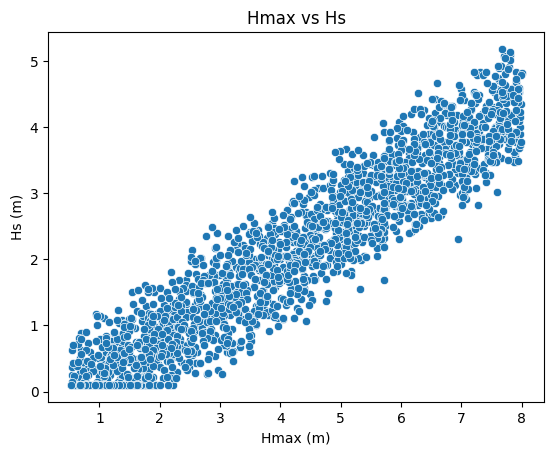

In [17]:
# 1. Hmax vs Hs
sns.scatterplot(data=df, x="Hmax", y="Hs")
plt.title("Hmax vs Hs")
plt.xlabel("Hmax (m)")
plt.ylabel("Hs (m)")
plt.show()

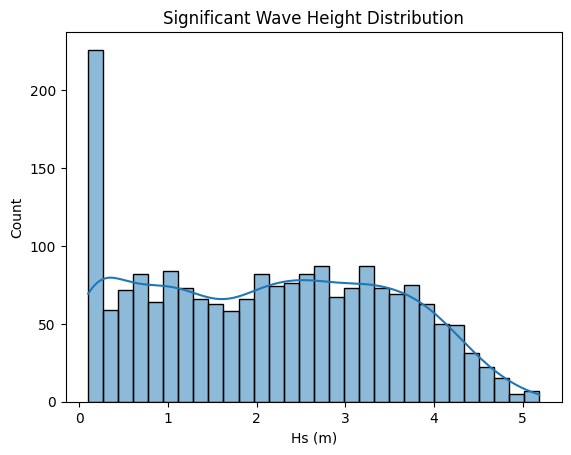

In [18]:
# 2. Hs Distribution
sns.histplot(data=df, x="Hs", bins=30, kde=True)
plt.title("Significant Wave Height Distribution")
plt.xlabel("Hs (m)")
plt.show()

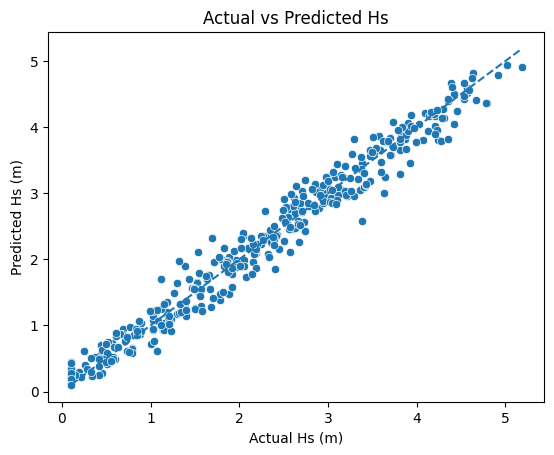

In [22]:
# 3. Actual vs Predicted Hs
sns.scatterplot(x=yhs_test, y=yhs_pred)
plt.plot([yhs_test.min(), yhs_test.max()],[yhs_test.min(), yhs_test.max()],"--")
plt.title("Actual vs Predicted Hs")
plt.xlabel("Actual Hs (m)")
plt.ylabel("Predicted Hs (m)")
plt.show()

---
## Summary

| Step | Task | Status |
|------|------|--------|
| 1 | Install & Import Libraries | ✅ |
| 2 | Generate Dataset | ✅ |
| 3 | Preprocessing | ✅ |
| 4 | Train Random Forest Models | ✅ |
| 5 | Evaluate Models (MAE, RMSE, R²) | ✅ |
| 6 | Save Models (.pkl) | ✅ |
| 7 | Prediction Function | ✅ |
| 8 | Safety Classification | ✅ |
| 9 | Test All Vessel Types | ✅ |
|10 | Visualization | ✅ |
> 🌊 **Project:** Smart Ocean Wave Prediction for Fisherman Safety using Random Forest Regression
